<a href="https://colab.research.google.com/github/AiRenad/ML-Social-media-productivity-Exploratory-Data-Analysis/blob/main/Social_media_productivity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ARTI406 - Machine Learning

# Assignment 1: Exploratory Data Analysis (EDA)

EDA is the first and most important step in any Machine Learning project.
Before building models, we must understand:

- What does the data represent?
- Are there missing values?
- Are there outliers?
- What patterns exist?
- Which variables influence others?

If we do not understand the data, we cannot build a good model.

### Why EDA is Important

In real-world machine learning projects:

    1- 70–80% of the time is spent on understanding and cleaning data
    2- Only 20–30% is spent building models

**EDA helps us:**

- Detect errors
- Identify trends
- Discover relationships
- Make business decisions

![step1.png](attachment:step1.png)

# Social Media Productivity Analysis

This project analyzes how social media usage, study habits, and lifestyle factors affect productivity.

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look cleaner
sns.set()

In [ ]:
# Load Dataset
df = pd.read_csv("/content/social_media_productivity_6000.csv")
df.head(50)

,age,daily_screen_time,social_media_hours,study_hours,sleep_hours,notifications_per_day,focus_score,addiction_level,productivity_score
0,21.0,5.95,2.81,2.61,6.99,283.0,100.00,Medium,28.49
1,34.0,3.82,2.33,0.28,7.47,266.0,93.65,Medium,18.54
2,29.0,3.57,1.64,5.21,6.34,137.0,100.00,Low,68.52
3,25.0,10.27,4.37,4.28,4.49,247.0,94.71,Medium,27.82
4,22.0,2.42,1.60,3.67,6.34,28.0,100.00,Low,51.09
5,35.0,6.19,2.19,7.26,4.41,218.0,100.00,Medium,67.38
6,21.0,3.68,1.23,1.34,7.41,296.0,100.00,Low,37.22
7,33.0,10.79,5.65,0.08,7.95,148.0,83.64,High,0.00
8,37.0,7.57,5.54,0.59,8.81,81.0,94.43,High,0.00
9,25.0,4.31,2.73,1.79,4.74,21.0,100.00,Medium,41.86


### Check Missing Values

In [ ]:
print(df.isna().sum())

age                      120
daily_screen_time        120
social_media_hours       120
study_hours              120
sleep_hours              120
notifications_per_day    120
focus_score              120
addiction_level          120
productivity_score       120
dtype: int64


Missing values were found in all columns, with 120 missing values in each column. Therefore, data cleaning was necessary before analysis.

###Check duplicated rows

In [ ]:
df.duplicated()[df.duplicated()==True]

,0


No duplicated rows, so there will be no distort analysis by counting the same transaction multiple times.

###Handeling missing values in numerical columns

In [ ]:
num_cols = df.select_dtypes(include='float64').columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)
df.head()

/tmp/ipykernel_6943/1544511715.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


,age,daily_screen_time,social_media_hours,study_hours,sleep_hours,notifications_per_day,focus_score,addiction_level,productivity_score
0,21.0,5.95,2.81,2.61,6.99,283.0,100.00,Medium,28.49
1,34.0,3.82,2.33,0.28,7.47,266.0,93.65,Medium,18.54
2,29.0,3.57,1.64,5.21,6.34,137.0,100.00,Low,68.52
3,25.0,10.27,4.37,4.28,4.49,247.0,94.71,Medium,27.82
4,22.0,2.42,1.60,3.67,6.34,28.0,100.00,Low,51.09


Missing values in numerical columns were filled using the median to reduce the effect of outliers and preserve the distribution of the data.

###Handeling missing values in categorical columns

In [ ]:
df['addiction_level'].fillna(df['addiction_level'].mode()[0], inplace=True)
df.head()

,age,daily_screen_time,social_media_hours,study_hours,sleep_hours,notifications_per_day,focus_score,addiction_level,productivity_score
0,21.0,5.95,2.81,2.61,6.99,283.0,100.00,Medium,28.49
1,34.0,3.82,2.33,0.28,7.47,266.0,93.65,Medium,18.54
2,29.0,3.57,1.64,5.21,6.34,137.0,100.00,Low,68.52
3,25.0,10.27,4.37,4.28,4.49,247.0,94.71,Medium,27.82
4,22.0,2.42,1.60,3.67,6.34,28.0,100.00,Low,51.09


The missing values in the categorical column addiction_level were filled using the mode, which represents the most frequent category in the dataset.

###Check that we handeled all the missing values

In [ ]:
df.isnull().sum()

,0
age,0
daily_screen_time,0
social_media_hours,0
study_hours,0
sleep_hours,0
notifications_per_day,0
focus_score,0
addiction_level,0
productivity_score,0


### No. of rows and columns

In [ ]:
print("Shape (rows, columns): ", df.shape,"\n")

print("number of rows: ", df.shape[0])
print("number of columns: ", df.shape[1])

Shape (rows, columns):  (6000, 9) 

number of rows:  6000
number of columns:  9


### Data type of columns

In [ ]:
df.dtypes

,0
age,float64
daily_screen_time,float64
social_media_hours,float64
study_hours,float64
sleep_hours,float64
notifications_per_day,float64
focus_score,float64
addiction_level,object
productivity_score,float64


we need to have correct data types for proper analysis.numeric types for  numerical operations.

**Converting Data Types to anothers**

In [ ]:
df['addiction_level'] = df['addiction_level'].astype('category')
df['age'] = df['age'].astype(int)
df['notifications_per_day'] = df['notifications_per_day'].astype(int)

df.dtypes

,0
age,int64
daily_screen_time,float64
social_media_hours,float64
study_hours,float64
sleep_hours,float64
notifications_per_day,int64
focus_score,float64
addiction_level,category
productivity_score,float64


Some numerical columns such as age and notifications_per_day were converted to integer type to better represent discrete values, while categorical columns were converted to appropriate data types..

In [ ]:
# Statistical summary
df.describe(include='all')

,age,daily_screen_time,social_media_hours,study_hours,sleep_hours,notifications_per_day,focus_score,addiction_level,productivity_score
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000,6000.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Medium,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3184,NaN
mean,27.109167,6.921912,4.138097,4.070242,6.514485,159.785833,96.436260,NaN,37.585770
std,7.195384,2.830329,2.134531,2.286266,1.419934,80.229995,7.359915,NaN,27.326495
min,15.000000,2.000000,0.660000,0.000000,4.000000,20.000000,47.390000,NaN,0.000000
25%,21.000000,4.520000,2.430000,2.160000,5.300000,90.000000,96.565000,NaN,14.310000
50%,27.000000,6.860000,3.755000,4.115000,6.525000,160.000000,100.000000,NaN,36.200000
75%,33.000000,9.312500,5.490000,6.000000,7.700000,230.000000,100.000000,NaN,58.135000


Here’s a shorter, clean version you can use:

> The `describe(include='all')` function provides summary statistics for both numerical and categorical data, helping to understand the distribution, key values, and most frequent categories in the dataset.


### Descriptive summary Statistics

### Univariate Analysis

##Productivity Score

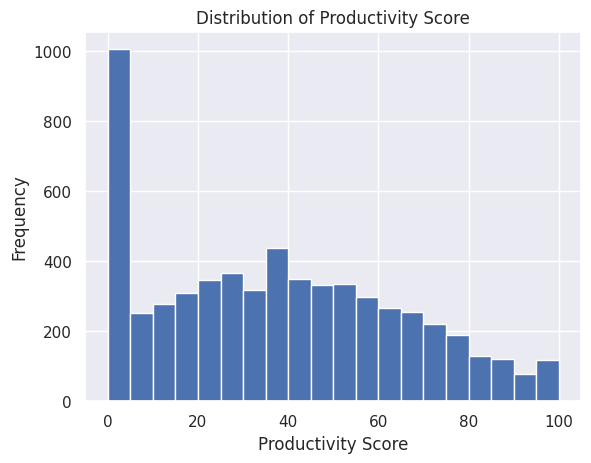

In [ ]:
plt.hist(df['productivity_score'], bins=20)
plt.title('Distribution of Productivity Score')
plt.xlabel('Productivity Score')
plt.ylabel('Frequency')
plt.show()

The histogram shows the distribution of productivity scores. Most values are concentrated in the middle range, indicating moderate productivity levels among individuals.

##Study Hours

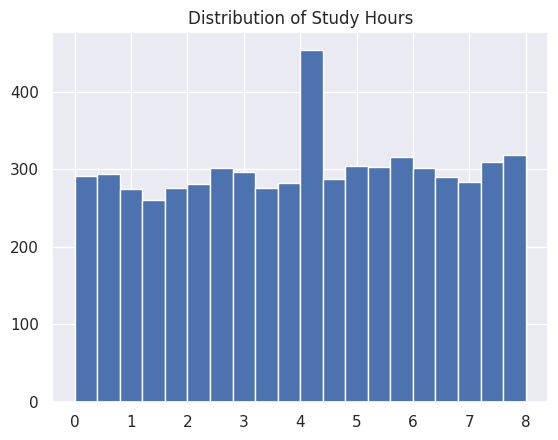

In [ ]:
plt.hist(df['study_hours'], bins=20)
plt.title('Distribution of Study Hours')
plt.show()

Study hours are distributed across a reasonable range, showing variation in how much individuals dedicate time to studying.

## Categorical Analysis



##Addiction Level

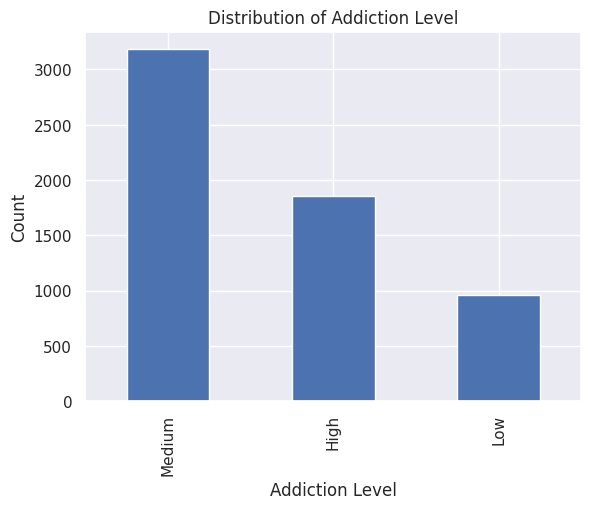

In [ ]:
df['addiction_level'].value_counts().plot(kind='bar')
plt.title('Distribution of Addiction Level')
plt.xlabel('Addiction Level')
plt.ylabel('Count')
plt.show()

This chart shows the frequency of each addiction level category. It helps identify the most common addiction level among individuals.

## Bivariate Analysis

##Screen Time vs Productivity

/tmp/ipykernel_6943/3737447638.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('screen_group')['productivity_score'].mean().plot(kind='bar')


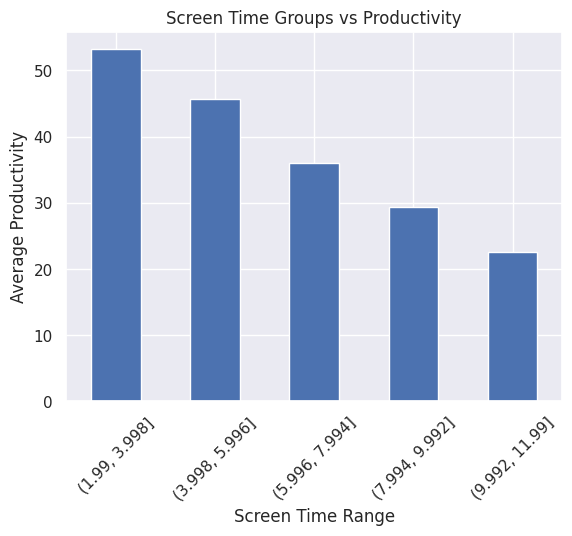

In [ ]:
df['screen_group'] = pd.cut(df['daily_screen_time'], bins=5)

df.groupby('screen_group')['productivity_score'].mean().plot(kind='bar')
plt.title('Screen Time Groups vs Productivity')
plt.xlabel('Screen Time Range')
plt.ylabel('Average Productivity')
plt.xticks(rotation=45)
plt.show()

The grouped bar chart clearly shows that lower screen time is associated with higher productivity, while higher screen time corresponds to lower productivity.

##Study Hours vs Productivity

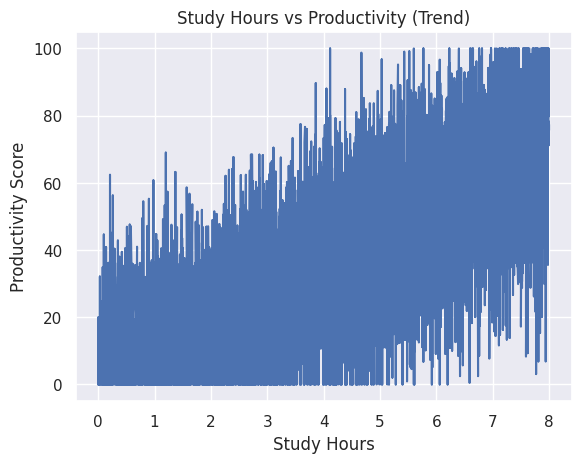

In [ ]:
df_sorted = df.sort_values(by='study_hours')
plt.plot(df_sorted['study_hours'], df_sorted['productivity_score'])
plt.title('Study Hours vs Productivity (Trend)')
plt.xlabel('Study Hours')
plt.ylabel('Productivity Score')
plt.show()

The line plot shows a general increasing trend, where productivity improves as study hours increase

##Correlation Analysis

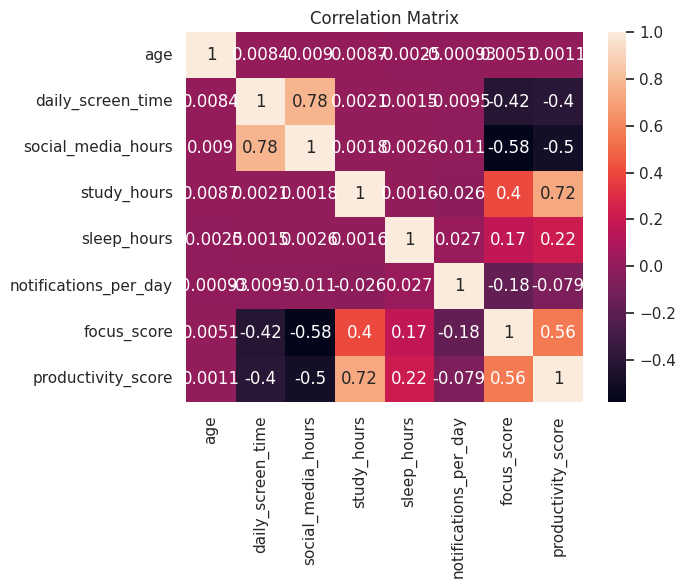

In [ ]:
import seaborn as sns

numeric_df = df.select_dtypes(include=['float64', 'int64'])

sns.heatmap(numeric_df.corr(), annot=True)
plt.title('Correlation Matrix')
plt.show()

Only numerical columns were selected to compute the correlation matrix, as correlation requires numeric data. Categorical variables were excluded from this analysis.

## Time-Based Analysis

##Screen Time vs Productivity (time-related behavior)

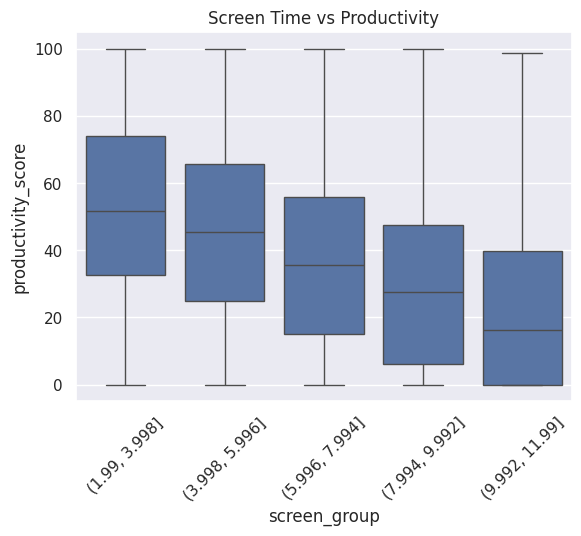

In [ ]:
import seaborn as sns

df['screen_group'] = pd.cut(df['daily_screen_time'], bins=5)

sns.boxplot(x='screen_group', y='productivity_score', data=df)
plt.title('Screen Time vs Productivity')
plt.xticks(rotation=45)
plt.show()

The boxplot shows that productivity decreases as screen time increases. Higher screen time groups have lower median productivity.

##Study Hours vs Productivity

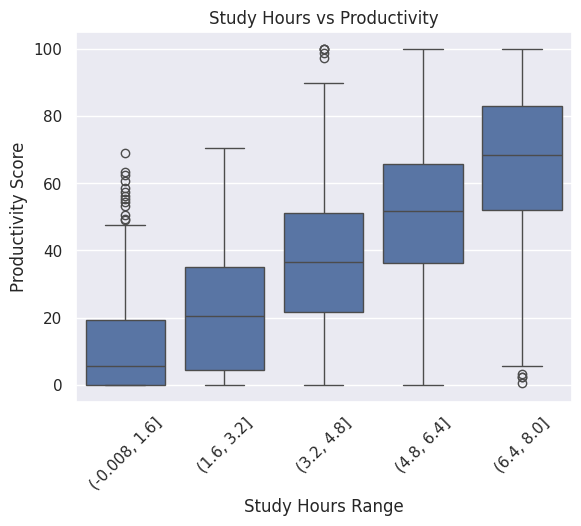

In [ ]:
import seaborn as sns

df['study_group'] = pd.cut(df['study_hours'], bins=5)

sns.boxplot(x='study_group', y='productivity_score', data=df)
plt.title('Study Hours vs Productivity')
plt.xlabel('Study Hours Range')
plt.ylabel('Productivity Score')
plt.xticks(rotation=45)
plt.show()

The boxplot shows the relationship between study hours and productivity. It can be observed that higher study hour groups tend to have higher median productivity scores, indicating a positive relationship between study time and productivity.

##Sleep Hours vs Productivity

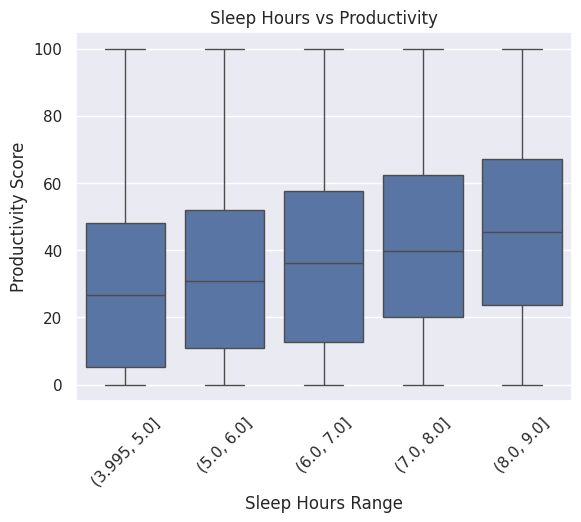

In [ ]:
import seaborn as sns

df['sleep_group'] = pd.cut(df['sleep_hours'], bins=5)

sns.boxplot(x='sleep_group', y='productivity_score', data=df)
plt.title('Sleep Hours vs Productivity')
plt.xlabel('Sleep Hours Range')
plt.ylabel('Productivity Score')
plt.xticks(rotation=45)
plt.show()

The boxplot indicates that productivity is highest at moderate sleep levels, suggesting that balanced sleep contributes to better performance. Both insufficient and excessive sleep are associated with lower productivity.

In [ ]:
df.head(50)

,age,daily_screen_time,social_media_hours,study_hours,sleep_hours,notifications_per_day,focus_score,addiction_level,productivity_score,screen_group,study_group,sleep_group
0,21,5.95,2.810,2.610,6.990,283,100.00,Medium,28.49,"(3.998, 5.996]","(1.6, 3.2]","(6.0, 7.0]"
1,34,3.82,2.330,0.280,7.470,266,93.65,Medium,18.54,"(1.99, 3.998]","(-0.008, 1.6]","(7.0, 8.0]"
2,29,3.57,1.640,5.210,6.340,137,100.00,Low,68.52,"(1.99, 3.998]","(4.8, 6.4]","(6.0, 7.0]"
3,25,10.27,4.370,4.280,4.490,247,94.71,Medium,27.82,"(9.992, 11.99]","(3.2, 4.8]","(3.995, 5.0]"
4,22,2.42,1.600,3.670,6.340,28,100.00,Low,51.09,"(1.99, 3.998]","(3.2, 4.8]","(6.0, 7.0]"
5,35,6.19,2.190,7.260,4.410,218,100.00,Medium,67.38,"(5.996, 7.994]","(6.4, 8.0]","(3.995, 5.0]"
6,21,3.68,1.230,1.340,7.410,296,100.00,Low,37.22,"(1.99, 3.998]","(-0.008, 1.6]","(7.0, 8.0]"
7,33,10.79,5.650,0.080,7.950,148,83.64,High,0.00,"(9.992, 11.99]","(-0.008, 1.6]","(7.0, 8.0]"
8,37,7.57,5.540,0.590,8.810,81,94.43,High,0.00,"(5.996, 7.994]","(-0.008, 1.6]","(8.0, 9.0]"
9,25,4.31,2.730,1.790,4.740,21,100.00,Medium,41.86,"(3.998, 5.996]","(1.6, 3.2]","(3.995, 5.0]"


# Assignment

In this assignment, you will apply the EDA techniques learned in class to a dataset of your choice. You must submit the following to the assignment 1 folder.
1. Dataset file
2. Dataset Description readme file
2. Jupyter Notebook
